In [1]:
pip install yfinance pandas matplotlib requests beautifulsoup4 plotly


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [40]:
#Question 1 - Extracting Tesla Stock Data Using yfinance
import yfinance as yf
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Extract Tesla stock data
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")

# Display top rows
df=pd.DataFrame(tesla_data.head())
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [41]:
#Question 2 - Extracting Tesla Revenue Data Using Webscraping 
import requests
from bs4 import BeautifulSoup

url_tesla = "https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
headers = {"User-Agent": "Mozilla/5.0"}
html_tesla = requests.get(url_tesla, headers=headers).text
soup_tesla = BeautifulSoup(html_tesla, "html.parser")

tables_tesla = soup_tesla.find_all("table")
tesla_table = None
for table in tables_tesla:
    if "Tesla Quarterly Revenue" in str(table):
        tesla_table = table
        break

if tesla_table:
    tesla_revenue = pd.read_html(str(tesla_table))[0]
    tesla_revenue.columns = ["Date", "Revenue"]
    tesla_revenue = tesla_revenue[tesla_revenue["Revenue"] != ""]
    tesla_revenue["Date"] = pd.to_datetime(tesla_revenue["Date"])
    tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(r'[\$,]', '', regex=True).astype(float)
else:
    tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])
tesla_revenue

,Date,Revenue
0,2025-03-31,19335.0
1,2024-12-31,25707.0
2,2024-09-30,25182.0
3,2024-06-30,25500.0
4,2024-03-31,21301.0
...,...,...
59,2010-06-30,28.0
60,2010-03-31,21.0
61,2009-12-31,NaN
62,2009-09-30,46.0


In [42]:
#Question 3 - Extracting GameStop Stock Data Using yfinance
gme = yf.Ticker("GME")
gme_data = gme.history(period="max").reset_index()
gme_data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0
...,...,...,...,...,...,...,...,...
5854,2025-05-20 00:00:00-04:00,27.889999,28.780001,27.850000,28.510000,4795100,0.0,0.0
5855,2025-05-21 00:00:00-04:00,28.400000,29.190001,28.020000,28.049999,8762000,0.0,0.0
5856,2025-05-22 00:00:00-04:00,28.549999,31.000000,28.490000,30.860001,21451000,0.0,0.0
5857,2025-05-23 00:00:00-04:00,30.600000,33.209999,30.549999,33.029999,30477600,0.0,0.0


In [43]:
#Question 4 - Extracting GameStop Revenue Data Using Webscraping
url_gme = "https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"
html_gme = requests.get(url_gme, headers=headers).text
soup_gme = BeautifulSoup(html_gme, "html.parser")

tables_gme = soup_gme.find_all("table")
gme_table = None
for table in tables_gme:
    if "GameStop Quarterly Revenue" in str(table):
        gme_table = table
        break

if gme_table:
    gme_revenue = pd.read_html(str(gme_table))[0]
    gme_revenue.columns = ["Date", "Revenue"]
    gme_revenue = gme_revenue[gme_revenue["Revenue"] != ""]
    gme_revenue["Date"] = pd.to_datetime(gme_revenue["Date"])
    gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(r'[\$,]', '', regex=True).astype(float)
else:
    gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])
gme_revenue

,Date,Revenue
0,2025-01-31,1283.0
1,2024-10-31,860.0
2,2024-07-31,798.0
3,2024-04-30,882.0
4,2024-01-31,1794.0
...,...,...
60,2010-01-31,3524.0
61,2009-10-31,1835.0
62,2009-07-31,1739.0
63,2009-04-30,1981.0


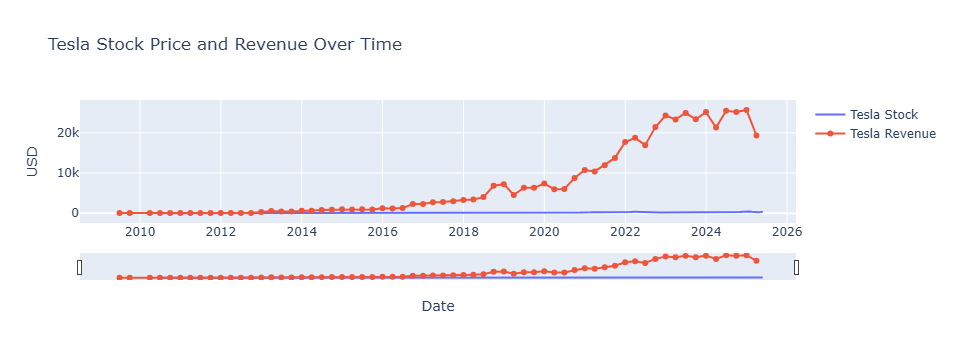

In [44]:
#Question 5 - Tesla Stock and Revenue Dashboard
import plotly.graph_objects as go
import pandas as pd
# Fix: Reset index to move 'Date' from index to column
tesla_data = tesla_data.reset_index()
# Ensure data types and clean up
tesla_data["Date"] = pd.to_datetime(tesla_data["Date"])
tesla_revenue["Date"] = pd.to_datetime(tesla_revenue["Date"])
tesla_revenue["Revenue"] = pd.to_numeric(tesla_revenue["Revenue"], errors="coerce")
# Drop rows with missing values
tesla_data.dropna(subset=["Date", "Close"], inplace=True)
tesla_revenue.dropna(subset=["Date", "Revenue"], inplace=True)
# Plotly visualization
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=tesla_data["Date"],
    y=tesla_data["Close"],
    mode='lines',
    name='Tesla Stock'
))
fig.add_trace(go.Scatter(
    x=tesla_revenue["Date"],
    y=tesla_revenue["Revenue"],
    mode='lines+markers',
    name='Tesla Revenue'
))
fig.update_layout(
    title='Tesla Stock Price and Revenue Over Time',
    xaxis_title='Date',
    yaxis_title='USD',
    xaxis_rangeslider_visible=True
)
fig.show()

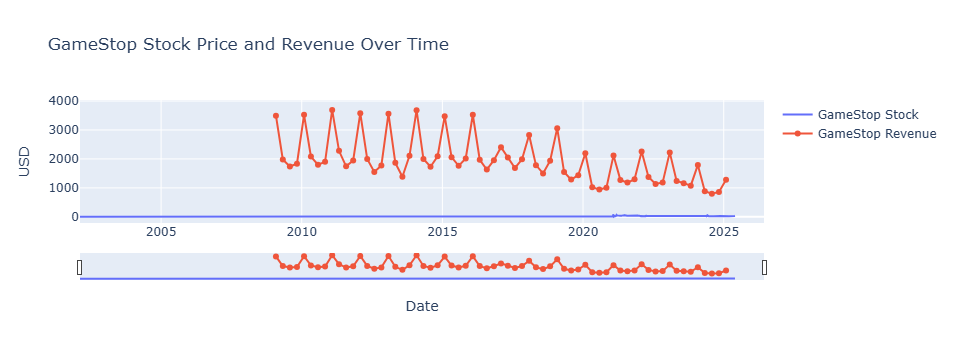

In [45]:
#Q6: GameStop Stock and Revenue Dashboard
fig = go.Figure()
fig.add_trace(go.Scatter(x=gme_data["Date"], y=gme_data["Close"], mode='lines', name='GameStop Stock'))
fig.add_trace(go.Scatter(x=gme_revenue["Date"], y=gme_revenue["Revenue"], mode='lines+markers', name='GameStop Revenue'))

fig.update_layout(
    title='GameStop Stock Price and Revenue Over Time',
    xaxis_title='Date',
    yaxis_title='USD',
    xaxis_rangeslider_visible=True
)
fig.show()
